# Forward Stepwise Selection for Phishing URL Classification
target encoding: **1 = legitimate**, **0 = phishing**.


In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt


In [2]:
df_train = pd.read_csv("../data/processed/train_lin.csv")
df_test = pd.read_csv("../data/processed/test_lin.csv")

In [3]:
def forward_stepwise_selection(X, y, p_enter=0.01, max_features=None, verbose=True):
    """
    Forward stepwise feature selection using p-values from statsmodels Logit.
    Stops when no remaining feature has p-value < p_enter.
    """
    selected = []
    remaining = list(X.columns)
    history = []

    if max_features is None:
        max_features = len(remaining)

    for step in range(max_features):
        best_feature = None
        best_p = np.inf
        best_model = None

        for feature in remaining:
            trial_features = selected + [feature]
            X_trial = sm.add_constant(X[trial_features], has_constant='add')
            try:
                model = sm.Logit(y, X_trial).fit(disp=0, method='lbfgs', maxiter=200)
                pval = model.pvalues.get(feature, np.inf)
            except Exception:
                continue

            if pval < best_p:
                best_p = pval
                best_feature = feature
                best_model = model

        if best_feature is None or best_p >= p_enter:
            if verbose:
                print(f'Stopping at step {step+1}: no feature met p < {p_enter}.')
            break

        selected.append(best_feature)
        remaining.remove(best_feature)
        history.append({
            'step': step + 1,
            'feature': best_feature,
            'p_value': float(best_p),
            'aic': float(best_model.aic),
            'bic': float(best_model.bic),
            'pseudo_r2': float(best_model.prsquared),
        })

        if verbose:
            print(f"Step {step+1}: added '{best_feature}' (p={best_p:.3e}, AIC={best_model.aic:.2f})")

    history_df = pd.DataFrame(history)
    return selected, history_df


In [ ]:
X_train = df_train.drop(columns=['label'])
y_train = df_train['label'].astype(int)

X_test = df_test.drop(columns=['label'])
y_test = df_test['label'].astype(int)

# Drop overly strong/leaky predictor(s) before stepwise selection
drop_candidates = ['URLSimilarityIndex']
actual_drop = [c for c in drop_candidates if c in X_train.columns]
if actual_drop:
    X_train = X_train.drop(columns=actual_drop)
    X_test = X_test.drop(columns=actual_drop, errors='ignore')
print('Dropped columns:', actual_drop if actual_drop else 'None')

# Forward stepwise selection (stricter p-value to keep model compact)
selected_features, selection_history = forward_stepwise_selection(
    X_train, y_train, p_enter=0.01, max_features=40, verbose=True
)

if len(selected_features) == 0:
    raise RuntimeError('No features were selected. Try a larger p_enter (e.g., 0.05).')

print(f'\nTotal selected features: {len(selected_features)}')
print(selected_features)
#print('Was URLSimilarityIndex selected?:', 'URLSimilarityIndex' in selected_features)
display(selection_history)

X_train_sel = sm.add_constant(X_train[selected_features], has_constant='add')
final_model = sm.Logit(y_train, X_train_sel).fit(disp=0, method='lbfgs', maxiter=300)
print(final_model.summary())


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Step 1: added 'URLLength' (p=0.000e+00, AIC=179821.76)


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\L

Step 2: added 'DomainLength' (p=0.000e+00, AIC=172775.71)


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
c:\

...

Stopping at step 28: no feature met p < 0.01.

Total selected features: 27
['URLLength', 'DomainLength', 'CharContinuationRate', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'NoOfLettersInURL', 'NoOfDegitsInURL', 'LetterRatioInURL', 'DegitRatioInURL', 'SpacialCharRatioInURL', 'LineOfCode', 'HasDescription', 'TLD_phishing_rate', 'NoOfImage', 'LargestLineLength', 'NoOfJS', 'NoOfEmptyRef', 'NoOfSelfRef', 'NoOfOtherSpecialCharsInURL', 'IsHTTPS', 'DomainTitleMatchScore', 'HasCopyrightInfo', 'HasExternalFormSubmit', 'NoOfExternalRef', 'Crypto', 'NoOfiFrame']


,step,feature,p_value,aic,bic,pseudo_r2
0,1,URLLength,0.000000e+00,179821.756287,179841.784367,0.202198
1,2,DomainLength,0.000000e+00,172775.707640,172805.749761,0.233469
2,3,CharContinuationRate,0.000000e+00,159099.472493,159139.528653,0.294155
3,4,URLCharProb,0.000000e+00,144668.440266,144718.510467,0.358190
4,5,TLDLength,0.000000e+00,140653.962412,140714.046653,0.376010
5,6,NoOfSubDomain,0.000000e+00,136727.935068,136798.033348,0.393438
6,7,NoOfLettersInURL,0.000000e+00,128531.674477,128611.786797,0.429811
7,8,NoOfDegitsInURL,0.000000e+00,51425.237659,51515.364020,0.771920
8,9,LetterRatioInURL,0.000000e+00,49770.893189,49871.033589,0.779269
9,10,DegitRatioInURL,0.000000e+00,46174.293542,46284.447983,0.795235


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


                           Logit Regression Results                           
Dep. Variable:                  label   No. Observations:               165056
Model:                          Logit   Df Residuals:                   165028
Method:                           MLE   Df Model:                           27
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                  0.9996
Time:                        02:26:20   Log-Likelihood:                -49.388
converged:                       True   LL-Null:                   -1.1270e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                        -47.4193   1.12e+07  -4.25e-06      1.000   -2.19e+07    2.19e+07
URLLength                    -30.8669    132.067     -0.234      0.815    -289.713 

c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


c:\Users\crazypepper\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\discrete\discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))


Test metrics (positive class = legitimate URL, label=1):
Accuracy : 0.9999
Precision: 1.0000
Recall   : 0.9999
F1-score : 0.9999
ROC-AUC  : 1.0000

Classification report:
                precision    recall  f1-score   support

  phishing (0)       1.00      1.00      1.00     15142
legitimate (1)       1.00      1.00      1.00     20228

      accuracy                           1.00     35370
     macro avg       1.00      1.00      1.00     35370
  weighted avg       1.00      1.00      1.00     35370

Confusion matrix [[TN, FP], [FN, TP]]:
[[15141     1]
 [    3 20225]]


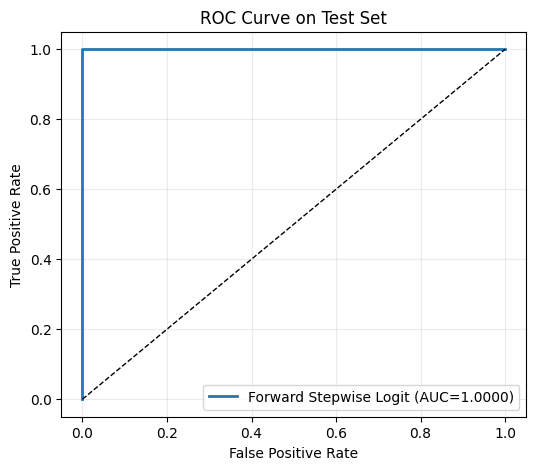

In [5]:
X_test_sel = sm.add_constant(X_test[selected_features], has_constant='add')
y_prob = final_model.predict(X_test_sel)
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print('Test metrics (positive class = legitimate URL, label=1):')
print(f'Accuracy : {acc:.4f}')
print(f'Precision: {prec:.4f}')
print(f'Recall   : {rec:.4f}')
print(f'F1-score : {f1:.4f}')
print(f'ROC-AUC  : {auc:.4f}')

print('\nClassification report:')
print(classification_report(y_test, y_pred, target_names=['phishing (0)', 'legitimate (1)']))

cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix [[TN, FP], [FN, TP]]:')
print(cm)

fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Forward Stepwise Logit (AUC={auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.show()
